# Sango Tutorial: General Introduction

Sango is a compositional domain-specific language (DSL) for constructing spiking neural network (SNN) architectures in Python. It is designed around a few high-level abstractions that make it easier to build modular, hierarchical, and reusable network descriptions and neuromorphic algorithms.

The name Sango is inspired by the Japanese word for coral, a common habitat for pufferfish (see the [Fugu](https://github.com/sandialabs/Fugu) project), and admits the backronym **Structured Abstractions for Network Group Organization**. One of the goals of Sango is to provide a modernized frontend to Fugu. We also plan on integrating it with other neuromorphic tools, simulators, and platforms.

The core idea is to organize complex networks like a filesystem:

- **Networks** are like folders or directories.
- **NodeGroups** and **EdgeGroups** are like files (containing concrete nodes and edges).
- **NodePorts** and **NodeLists** are like aliases or pointers that help connect pieces together more flexibly.

This tutorial expects some familiarity with Python and some exposure to SNN or neuromorphic computing frameworks such as Brian, NEST, PyNN, Lava, but may be new to Fugu's or Sango's compositional style of constructing networks. It will cover:

- Basic node and edge groups: `NodeGroup` and `EdgeGroup`
- Model parameters and per-node/per-edge states
- Networks and their hierarchical composition
- Alias classes: `NodePort` and `NodeList`
- Recursive build and dependency resolution
- Exporting to a graph and simulation backends

## 0.1 Motivation for yet another Domain-Specific Language

Many SNN tools organize networks as populations and projections (computational neuroscience) or as layers and connections (machine learning):

- populations/layers of neurons
- projections/connections of synapses between neurons

However, as neuromorphic algorithms become more complex, we may want to express ideas such as:

- "This network is made of several reusable subnetworks."
- "This subnetwork accepts an input of whatever size it is connected to."
- "Instantiate many copies of this subnetwork and connect them procedurally."
- "Gather particular neurons from different subnetworks into a single output."

Sango focuses on this higher-level task of **composing and managing network structures**

Rather than forcing the user to manually manage global neuron or edge indices, Sango lets us work locally with groups of nodes and relative references. Then, during the build process, Sango recursively constructs the full topology and flattens it into globally named nodes and edges.

## 0.2 The File System Mental Model

These core network components in Sango are implemented by the following classes:

- `Network`: the main compositional container (may contain subnetworks)
- `NodeGroup`: a group of nodes (e.g. neurons) with the same node model
- `EdgeGroup`: a group of edges (e.g. synapses) between two node sets
- `NodePort`: a placeholder or alias for external node sets (e.g. inputs to a subnetwork)
- `NodeList`: an explicit list of node references (e.g. outputs from different subnetworks)

A Sango network resembles a directory structure. When flattened (i.e. any references are fully resolved), each network component will be assigned its **full path name** within this hierarchy. This is useful for providing stable, human-readable identifiers for backend translation and debugging.

In addition to the core network components, Sango also allows for lists of these components for additional flexibility.

For example, suppose we write:

```python
net = Network()
net.layer = [NodeGroup(LIF(), 32), NodeGroup(LIF(), 10)]
net.dense = EdgeGroup(net.layer[0], net.layer[1], PSP(), edges=...)
```

Conceptually, the network contains:

```text
net/
├── layer[0]    # node group
├── layer[1]    # node group
└── dense       # edge group
```

Individual nodes receive path-like names such as:

```text
layer[0][0]
layer[0][1]
...
layer[1][9]
```

When networks are nested, the path names become hierarchical (using dot notation):

```text
encoder.input[5]
classifier[0].layer[3][6]
actuator[2].output[1]
```

This structure can also be thought of a nested attribute tree, where child networks are attributes of a parent network. The underlying topology structure is actually an extension of Python's `SimpleNamespace` data structure.

## 0.3 Dependencies and Installation

The Sango package requires Python 3.9 or above (for more advanced dataclass support). There are also two main dependencies that are currently required: NumPy and NetworkX. Finally, for this tutorial, we use the Brian 2 SNN simulator as a backend.

```bash
python -m pip install numpy networkx
python -m pip install brian2
```

```bash
git clone https://github.com/sandialabs/Sango.git
cd Sango
python -m pip install -e .
```

## 0.4 General Sango Imports

For this tutorial, we will import some general Python packages for working with network data.

We will also use the basic built-in SNN models in Sango:

- `IN`: spike generator input model
- `LIF`: leaky integrate-and-fire neuron model
- `PSP`: post-synaptic potential synapse model

In [1]:
import itertools
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP

# Basic Node and Edge Groups 

## 1.1 Node Groups

A `NodeGroup` is a list-like container of instantiated nodes that share the same node model.

The nodes within a node group are specified using **local indices**.

Here we create a small group of leaky integrate-and-fire neurons.

In [2]:
layer = NodeGroup(LIF(), size=3)

print(layer)
print("size:", layer.size)
print("voltage:", layer.voltage)
print("threshold:", layer.threshold)
print("leak:", layer.leak)

detached nodegroup
size: 3
voltage: [0. 0. 0.]
threshold: [1. 1. 1.]
leak: [1. 1. 1.]


Before the group is inserted into a network and built, it is "detached" and does not yet have a path name. But it is already a list of individual node objects with state parameters.

## 1.2 Model Data

Sango node and edge models are Python dataclasses. For example, the built-in `LIF` model includes fields such as:

- `voltage`
- `threshold`
- `reset`
- `bias`
- `leak`

When a `NodeGroup` is created, model fields are stored as NumPy arrays at the group level. Individual nodes hold views into those arrays. This means we can modify values either at the group level or at the individual node level.

In [3]:
layer = NodeGroup(
    LIF(threshold=0.9),   # model and any parameter defaults for this group
    size=3,               # number of neurons in group
    voltage=0.6,          # bulk assignment of parameters
    leak=[0.5, 0.4, 0.3]  # per-node parameter assignment
)

print("initial threshold:", layer.threshold)
print("initial voltage:", layer.voltage)
print("initial leak:", layer.leak)

# Modify one node
layer[1].voltage = 0.8
# Modify multiple nodes
layer.leak = [0.3, 0.4, 0.5]

print("updated voltage:", layer.voltage)
print("updated leak:", layer.leak)

initial threshold: [0.9 0.9 0.9]
initial voltage: [0.6 0.6 0.6]
initial leak: [0.5 0.4 0.3]
updated voltage: [0.6 0.8 0.6]
updated leak: [0.3 0.4 0.5]


## 1.3 Edge Groups

An `EdgeGroup` is a list-like container of instantiated edges between a source node set and a target node set.

The edges within an edge group are specified using **local indices relative to the source and target** sets, respectively.

For example, if we define:

```python
edges = [(0, 1), (1, 2), (2, 0)]
```

this means:

- source node 0 connects to target node 1
- source node 1 connects to target node 2
- source node 2 connects to target node 0

There is also an `edge_map` that gets constructed by the edge group to locally to map these tuples to simple linear ordering.

In [4]:
source = NodeGroup(LIF(), size=3)
target = NodeGroup(LIF(), size=3)

edges = [(0, 1), (1, 2), (2, 0)]

conn = EdgeGroup(
    source,                 # source node group
    target,                 # target node group
    PSP(delay=2.0),         # model and defaults
    edges=edges,            # list of edge tuples
    weight=[1.0, 2.0, 3.0]  # per-edge assignment
)

print("edges:", conn.edges)
print("source indices:", conn.source_index)
print("target indices:", conn.target_index)
print("edge map:", conn.edge_map)

print("delay:", conn.delay)
print("weight:", conn.weight)

edges: [(0, 1), (1, 2), (2, 0)]
source indices: [0, 1, 2]
target indices: [1, 2, 0]
edge map: {(0, 1): 0, (1, 2): 1, (2, 0): 2}
delay: [2. 2. 2.]
weight: [1. 2. 3.]


Edges can be indexed either linearly or by their `(source_index, target_index)` tuple.

In [5]:
conn[(1, 2)].delay = 3.0
conn[0].weight = 1.5

print("delay:", conn.delay)
print("weight:", conn.weight)

delay: [2. 3. 2.]
weight: [1.5 2.  3. ]


# Networks

## 2.1 Simple Networks

With just the `NodeGroup` and `EdgeGroup`, it is possible to construct simple `Network` stuctures. This is almost no different that what many existing tools provide, with perhaps the exception that a `Network` can also be nested within a `Network`.

**Network components are assigned as attributes** of an instantiated `Network` object. This is the primary user-facing syntax in Sango.

In [6]:
net = Network()

net.input = NodeGroup(IN(), size=2, times=[[0, 2, 4], [1, 3, 5]])
net.hidden = NodeGroup(LIF(threshold=1.0, leak=0.8), size=4)

dense_edges = list(itertools.product(range(net.input.size), range(net.hidden.size)))

net.input_to_hidden = EdgeGroup(net.input, net.hidden,
                                PSP(weight=1.0, delay=1.0),
                                edges=dense_edges)

net.output = NodeList([net.hidden[0], net.hidden[2]])

net.build()

print(net)

info: flattening network topology
(node) input
(node) hidden
(edge) input_to_hidden: (node) input -> (node) hidden
(list) output


After `build()`, Sango has assigned path names to the concrete nodes and resolved the edge endpoints.

In [7]:
for node in net.hidden:
    print(node.name)

hidden[0]
hidden[1]
hidden[2]
hidden[3]


In [8]:
for edge in net.input_to_hidden[:6]:
    print(edge)

input[0] -> hidden[0]
input[0] -> hidden[1]
input[0] -> hidden[2]
input[0] -> hidden[3]
input[1] -> hidden[0]
input[1] -> hidden[1]


## 2.2 NodeLists

In the example above, we also introduced the `NodeList` class. This is an alias-style class containing references to instantiated nodes.

For example:

```python
net.output = NodeList([net.hidden[0], net.hidden[2]])
```

This says that the output of the network is the first and third hidden neuron.

A `NodeList` can also contain nodes from multiple groups. While not a new node group itself, it can be used in place of a node group with respect to network connectivity.

In [9]:
for node in net.output:
    print(node.name)

hidden[0]
hidden[2]


## 2.3 NodePorts

The other alias class in Sango is the `NodePort`. Together, these alias classes are what let Sango support flexible composition.

A `NodePort` is a placeholder for a list of nodes that will be supplied later (either from a basic `NodeGroup` or from a `NodeList`)

`NodePort`s may be initialized with a known size, or left uninitialized. In the latter case, this creates a build dependency where the network containing the node port cannot be built until it has been resolved.

To resolve the build dependence on an uninitialized `NodePort`, we `bind()` it to a source set of nodes.

```python
net.bind(source_nodes, target_port)
```

Note: node ports that were initialized with a size must still be bound during the build process (this should not change its size). This is useful for resolving potential circular dependencies where ports may need to have their size set manually with `set_portsize(port, size)`.

## 2.4 Defining Network Classes

Sango allows subclassing `Network` to create reusable and composable network components.

There are two main methods that need to be updated in this subclass:

- `__init__()`: declare parameters and any node ports
- `build()`: assign node groups, edge groups, and lists

Here we define a sparsely connected delay layer. It has an unsized input port, so the layer can adapt to whatever input size it is connected to.

This design pattern, where networks define a node port in `__init__()` and then construct edges from that input in `build()`, is especially important for reusable network classes. Used in this way, a `NodePort` acts as an input interface for a network.

In [10]:
# Layer with random sparse and delayed projections
class SparseDelayLayer(Network):
    def __init__(self, size=8, seed=None,
                 prob=0.4, leak=0.9,
                 delay_min=1.0, delay_max=5.0,
                 weight_min=0.5, weight_max=1.5):
        super().__init__()
        # Object parameters
        self.size = size
        self.seed = seed
        self.prob = prob
        self.leak = leak
        self.delay_min = delay_min
        self.delay_max = delay_max
        self.weight_min = weight_min
        self.weight_max = weight_max

        # Random number generator
        self.rng = np.random.default_rng(self.seed)

        # Unsized input port
        self.input = NodePort()
        
    # Helper function for edges
    def get_rand_proj(self, prob, num_s, num_t):
        edges = set()
        assert 0.0 <= prob <= 1.0, f"Probability {prob} is not between 0.0 and 1.0"
        num = int(prob * num_s * num_t)
        while len(edges) < num:
            s = self.rng.integers(num_s)
            t = self.rng.integers(num_t)
            edges.add((s,t))
        return list(edges)

    # Build function (will execute after input port is resolved)
    def build(self):
        # Main neuron population
        self.layer = NodeGroup(LIF(leak=self.leak), self.size)

        # Sparse random projection
        edges = self.get_rand_proj(self.prob, self.input.size, self.layer.size)

        # Per-edge delays and weights
        delays = self.rng.integers(int(self.delay_min), int(self.delay_max) + 1,
                              size=len(edges)).astype(float)

        weights = self.rng.uniform(self.weight_min,self.weight_max,
                              size=len(edges))

        # Input to layer connections
        self.proj = EdgeGroup(self.input, self.layer, PSP(),
                              edges=edges, delay=delays, weight=weights)

        # Output list (here, it's the same as layer)
        self.output = NodeList(self.layer)

## 2.5 Binding Ports

We can now use these subclassed networks within a larger network hierarchy. Here, we show binding the output from one network to the input of another network.

In [11]:
# Network Construction
net = Network()

# Input neurons
net.input = NodeGroup(IN(), 4, times=[[0],[1],[2],[3]])

# Sparse layer
net.layer = SparseDelayLayer(size=8, seed=5, prob=0.6, delay_min=1, delay_max=4)

# Bind the input neurons to input port in the network
net.bind(net.input, net.layer.input)

# Build and print the network topology
net.build()
print(net)

info: adding network layer
info: linking port layer.input
info: resolving dependency for layer.input
info: building network layer
info: flattening network topology
(node) input
(port) layer.input <- (node) input
(node) layer.layer
(edge) layer.proj: (port) layer.input <- (node) input -> (node) layer.layer
(list) layer.output


The printed network topology shows the port and what it is linked to. We can also see that for the edge groups that use node ports as their source, resolve to their referenced source nodes during flattening.

# Complex Networks

## 3.1 Recursive Build Process

In the previous example, some additional information during the build process was shown with respect to linking ports and resolving dependencies, after which the network we added was finally built.

This build process is both iterative and recursive over the network hierarchy. At a high level, it performs the following steps:

1. Identify any unresolved dependencies in child networks.
2. Apply port bindings if possible to resolve port sizes.
3. Build child networks whose dependencies are satisfied.
4. Recursively repeat this process until all child networks are built.
5. Flatten the network hierarchy onto full path names.

This is similar to a topological sort over the dependency structure.

## 3.2 Composing Multiple Networks

A key benefit of this deferred composition approach is that the resuable networks can be written without hard-coding their input size, but rather letting it be determined by its incoming connections.

This allows us to construct more complex network structures more flexibly from the same network components.

In [12]:
# Input network with spike times
class SpikeGenerator(Network):
    def __init__(self, spike_times):
        super().__init__()
        self.spike_times = spike_times # n x t (eventlist)

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        self.output = NodeList(self.spikegen[:])
        
        return

In [13]:
# Input spike trains with staggered activity
input_times = [[0, 9, 11],
               [2, 7, 12, 15],
               [5, 13, 17],
               [1, 6, 11, 20]]

# Network Construction
net = Network()

# Input network
net.sg = SpikeGenerator(spike_times=input_times)

# Feedforward chain of networks
net.ff = [
    SparseDelayLayer(size=8, seed=5, prob=0.6, delay_min=1, delay_max=4),
    SparseDelayLayer(size=10, seed=6, prob=0.4, delay_min=1, delay_max=5),
    SparseDelayLayer(size=4, seed=7, prob=0.4, delay_min=3,delay_max=6),
]

# Connect the outputs to inputs
net.bind(net.sg.output, net.ff[0].input)
net.bind(net.ff[0].output, net.ff[1].input)
net.bind(net.ff[1].output, net.ff[2].input)

# Build and print the network topology
net.build()
print(net)

info: adding network sg
info: adding list of networks ff
info: building network sg
info: linking port ff[0].input
info: waiting on source ff[0].output
info: waiting on source ff[1].output
info: resolving dependency for ff[0].input
info: building network ff[0]
info: linking port ff[1].input
info: waiting on source ff[1].output
info: resolving dependency for ff[1].input
info: building network ff[1]
info: linking port ff[2].input
info: resolving dependency for ff[2].input
info: building network ff[2]
info: flattening network topology
(port) ff[0].input <- (list) sg.output
(node) ff[0].layer
(edge) ff[0].proj: (port) ff[0].input <- (list) sg.output -> (node) ff[0].layer
(list) ff[0].output
(port) ff[1].input <- (list) ff[0].output
(node) ff[1].layer
(edge) ff[1].proj: (port) ff[1].input <- (list) ff[0].output -> (node) ff[1].layer
(list) ff[1].output
(port) ff[2].input <- (list) ff[1].output
(node) ff[2].layer
(edge) ff[2].proj: (port) ff[2].input <- (list) ff[1].output -> (node) ff[2].lay

## 3.3 Network Design Patterns

Here are a few useful design patterns for constructing more complex networks in Sango. We have seen some of these in the examples already.

### 3.3.1 Lists of networks

Lists of networks are particularly useful when building repeated structures. This also helps with naming, where each network in the list shares a base name and can be indexed through bracket notation.

Example structures where this may be relevant are: stacked network layers, distributed cortical columns, multiple dendritic branches, collection of mesh points, or repeated algorithmic kernels.

### 3.3.2 Node ports as input interfaces

Although a `NodePort` is more generically a placeholder for a node group, a standard way to use it is as a symbolic link to a node group that acts as the input into a network.

This gives the child network a local name for its input while allowing the parent network to decide where that input comes from. With respect to scope, the port binding of any child networks occurs in the parent network.

### 3.3.3 Node lists as output interfaces

Although a `NodeList` is more generically a collection of references to individual nodes, a standard way to use it is as flexible node group that acts as the output from a network.

While using a `NodeList` for output is not strictly necessary, is useful when the output is not simply a single `NodeGroup`, but perhaps a subset of one, collected from multiple node groups, or just for naming convenience.

### 3.3.4 Node lists as flexible node groups

Compared to a `NodePort` which can only be bound in one direction, a `NodeList` can be used as either the source or target of an `EdgeGroup`, or also as a source to be bound to a `NodePort`. 

This flexibility allows a `NodeList` to stand in for a `NodeGroup` more generally. For example, a parent network might have several child networks which expose only a single selected output neuron from each as a `NodeList`. And then a `NodeList` in the parent may concatenate these individual outputs into a collective input for downstream processing.

### 3.3.5 Networks as reusable modules

These input and output interfaces make it straightforward to wrap network structures and functions into reusable modules. Rather than attempting to define a large monolithic network structure, decomposing a neuromorphic algorithm into more manageable parts makes it easier to scale up designs while maintaining comprehensibility.

With respect to the general definition of a network, inputs as node ports are specified in the `__init()__` method, and its internal structure and any outputs are constructed in the `build()` method.

# Simulating networks

## 4.1 Exporting to NetworkX

Sango separates high-level network construction from backend execution. This encourages interoperability with the broader neuromorphic computing software ecosystem through an intermediate representation.

Although it is possible to work with the network topology structure more directly, Sango provides a more accessible export format to a NetworkX graph as just a flattened list of nodes and edges. This is useful for debugging, visualization, or for translating the network structure to a suitable simulation backend.

In [14]:
# Export to NetworkX
graph = net.graph()

# Print some graph information
print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())

print("\nExample nodes:")
for node, data in list(graph.nodes(data=True))[:5]:
    print(node, data)

print("\nExample edges:")
for source, target, data in list(graph.edges(data=True))[:5]:
    print(source, "->", target, data)

Number of nodes: 26
Number of edges: 67

Example nodes:
ff[0].layer[0] {'model': 'LIF', 'voltage': np.float64(0.0), 'threshold': np.float64(1.0), 'reset': np.float64(0.0), 'bias': np.float64(0.0), 'leak': np.float64(0.9)}
ff[0].layer[1] {'model': 'LIF', 'voltage': np.float64(0.0), 'threshold': np.float64(1.0), 'reset': np.float64(0.0), 'bias': np.float64(0.0), 'leak': np.float64(0.9)}
ff[0].layer[2] {'model': 'LIF', 'voltage': np.float64(0.0), 'threshold': np.float64(1.0), 'reset': np.float64(0.0), 'bias': np.float64(0.0), 'leak': np.float64(0.9)}
ff[0].layer[3] {'model': 'LIF', 'voltage': np.float64(0.0), 'threshold': np.float64(1.0), 'reset': np.float64(0.0), 'bias': np.float64(0.0), 'leak': np.float64(0.9)}
ff[0].layer[4] {'model': 'LIF', 'voltage': np.float64(0.0), 'threshold': np.float64(1.0), 'reset': np.float64(0.0), 'bias': np.float64(0.0), 'leak': np.float64(0.9)}

Example edges:
ff[0].layer[0] -> ff[1].layer[5] {'model': 'PSP', 'delay': np.float64(4.0), 'weight': np.float64(0

## 4.2 Visualization

Because the exported graph object is a NetworkX graph, we can use standard NetworkX tools for simple visualizations.

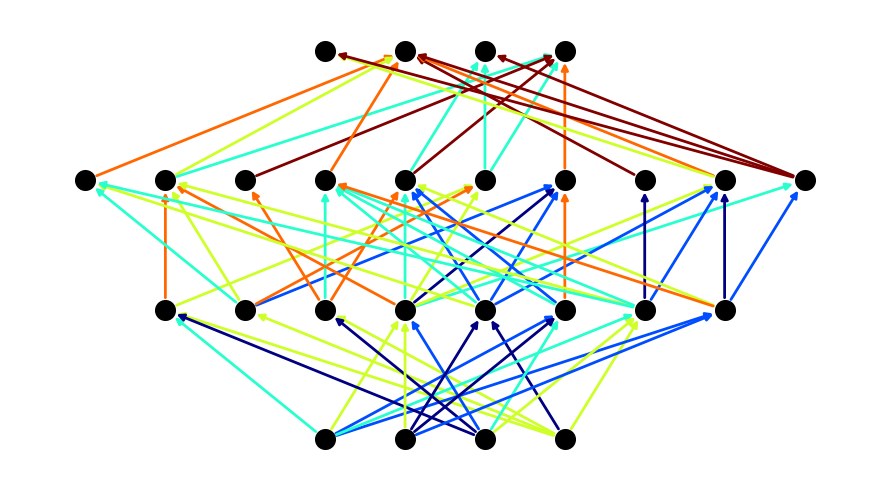

In [15]:
# Get graph for plotting structure
graph = net.graph()

# Modify the node positions a bit for the visualization
pos = nx.circular_layout(graph)
for i in range(len(net.sg.output)):
    pos[net.sg.output[i].name][0] = 1.0 * i / len(net.sg.output) - 0.5
    pos[net.sg.output[i].name][1] = 0.0

width = [2.0, 2.5, 1.0]
for l in range(len(net.ff)):
    for i in range(len(net.ff[l].output)):
        pos[net.ff[l].output[i].name][0] = width[l] * i / len(net.ff[l].output) - width[l] / 2
        pos[net.ff[l].output[i].name][1] = 1.0 + l

# Edge information (for delay color)
edge_list = list(graph.edges())
edge_delays = [graph.edges[source, target].get("delay", 1.0)
               for source, target in edge_list]
edge_norm = plt.Normalize(vmin=min(edge_delays), vmax=max(edge_delays))
edge_cmap = plt.get_cmap("jet")
edge_colors = [edge_cmap(edge_norm(delay)) for delay in edge_delays]

# Visualize
plt.figure(figsize=(9, 5))
nx.draw_networkx_nodes(graph, pos, node_size=200, node_color='black')
nx.draw_networkx_edges(graph, pos, edgelist=edge_list, edge_color=edge_colors, width=2.0)

plt.axis('off')
plt.tight_layout()

## 4.3 Simulation

Sango is primarily a frontend for describing the network topology. The simulation of the network dynamics is handled by a suitable backend. The exported NetworkX graph may be used under-the-hood to support this translation process.

For example, if the Brian backend is installed and supports the models used here, we can run:

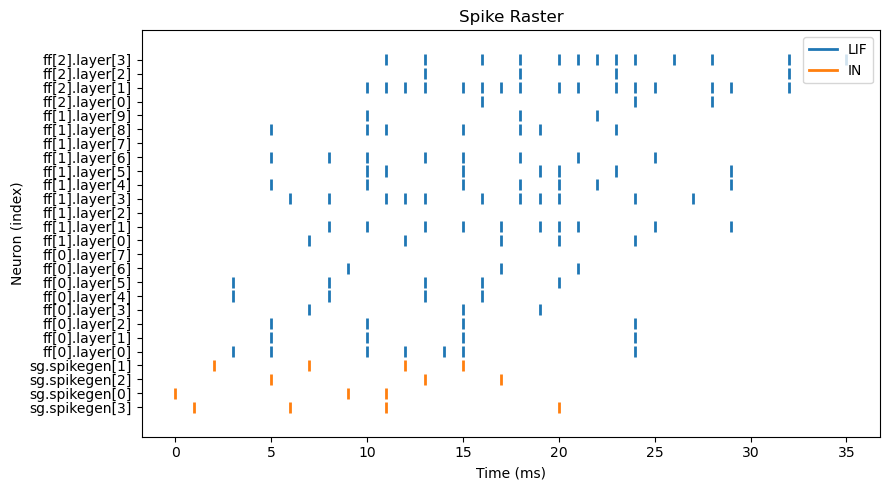

In [16]:
# Simple simulation in Brian
from sango.backend import SimBrian

sim = SimBrian(net)
sim.compile()
sim.run(40.0)

# Visualize the spike raster
sim.plot_spikes(figsize=(9, 5), linewidths=2.0, tick_names=True)

# Summary

Sango is a compositional domain-specific language (DSL) for constructing spiking neural network (SNN) architectures in Python. It provides a small set of high-level abstractions for building complex network architectures:

| Class | Description | Role |
|---|---|---|
| `Network` | Main compositional container, allows nesting | Modules |
| `NodeGroup` | Concrete group of nodes sharing a node model | Neurons |
| `EdgeGroup` | Concrete group of edges between node sets | Synapses |
| `NodePort` | Alias/placeholder for external node set | Inputs |
| `NodeList` | Alias/reference list of selected nodes | Outputs |

The key idea is that Sango lets you describe and manage the networks compositionally and hierarchically from modular network components. During build, it iteratively and recursively resolves dependencies, links ports, builds child networks, flattens path names, and produces a concrete network topology.

This makes it easier to write reusable network components, compose them into larger structures, and target different simulation or neuromorphic hardware backends.